<a href="https://colab.research.google.com/github/Mahesh527784/DataAnalyst/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd , numpy as np

In [19]:
univ = pd.read_csv('/content/Universities.csv')
univ1 = pd.read_csv('/content/Universities.csv')

**. Remove all records with missing measurements from the dataset. **

In [15]:
univ.head()

,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193.0,146.0,55.0,16.0,44.0,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.0
1,University of Alaska at Fairbanks,AK,1,1852.0,1427.0,928.0,NaN,NaN,3885.0,4519.0,1742.0,5226.0,1800.0,1790.0,155.0,650.0,2304.0,67.0,10.0,NaN
2,University of Alaska Southeast,AK,1,146.0,117.0,89.0,4.0,24.0,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.0
3,University of Alaska at Anchorage,AK,1,2065.0,1598.0,1162.0,NaN,NaN,6209.0,10537.0,1742.0,5226.0,2600.0,2520.0,114.0,580.0,1260.0,48.0,13.7,NaN
4,Alabama Agri. & Mech. Univ.,AL,1,2817.0,1920.0,984.0,NaN,NaN,3958.0,305.0,1700.0,3400.0,1108.0,1442.0,155.0,500.0,850.0,53.0,14.3,40.0


In [16]:
univ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   College Name              1302 non-null   object 
 1   State                     1302 non-null   object 
 2   Public (1)/ Private (2)   1302 non-null   int64  
 3   # appli. rec'd            1292 non-null   float64
 4   # appl. accepted          1291 non-null   float64
 5   # new stud. enrolled      1297 non-null   float64
 6   % new stud. from top 10%  1067 non-null   float64
 7   % new stud. from top 25%  1100 non-null   float64
 8   # FT undergrad            1299 non-null   float64
 9   # PT undergrad            1270 non-null   float64
 10  in-state tuition          1272 non-null   float64
 11  out-of-state tuition      1282 non-null   float64
 12  room                      981 non-null    float64
 13  board                     804 non-null    float64
 14  add. fee

In [21]:
univ.isnull().sum()



,0
College Name,0
State,0
Public (1)/ Private (2),0
# appli. rec'd,10
# appl. accepted,11
# new stud. enrolled,5
% new stud. from top 10%,235
% new stud. from top 25%,202
# FT undergrad,3
# PT undergrad,32


In [23]:
print(univ1.duplicated().sum())

0


In [24]:
# prompt: remove duplicate values

# Drop duplicate rows based on all columns
univ.drop_duplicates(inplace=True)

#To drop duplicates based on specific column(s):
# univ.drop_duplicates(subset=['Column1', 'Column2'], inplace=True)

print(univ.shape) # Print the shape to verify
univ.head()


(1302, 20)


,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193.0,146.0,55.0,16.0,44.0,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.0
1,University of Alaska at Fairbanks,AK,1,1852.0,1427.0,928.0,NaN,NaN,3885.0,4519.0,1742.0,5226.0,1800.0,1790.0,155.0,650.0,2304.0,67.0,10.0,NaN
2,University of Alaska Southeast,AK,1,146.0,117.0,89.0,4.0,24.0,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.0
3,University of Alaska at Anchorage,AK,1,2065.0,1598.0,1162.0,NaN,NaN,6209.0,10537.0,1742.0,5226.0,2600.0,2520.0,114.0,580.0,1260.0,48.0,13.7,NaN
4,Alabama Agri. & Mech. Univ.,AL,1,2817.0,1920.0,984.0,NaN,NaN,3958.0,305.0,1700.0,3400.0,1108.0,1442.0,155.0,500.0,850.0,53.0,14.3,40.0


In [34]:
# prompt: Using dataframe univ: convert college name and state columns data type into  string

# Convert the 'College Name' column to string data type.
univ['College Name'] = univ['College Name'].astype(str)

# Convert the 'State' column to string data type.
univ['State'] = univ['State'].astype(str)


In [35]:
# prompt: replace null value in a column  with mean value of the column for every column in a dataset

for col in univ.columns:
    if univ[col].dtype in ['int64', 'float64']:
        mean_value = univ[col].mean()
        univ[col].fillna(mean_value, inplace=True)


<ipython-input-35-073f3c718548>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  univ[col].fillna(mean_value, inplace=True)


In [38]:
univ.head()


,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193.0,146.0,55.0,16.000000,44.00,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.000000
1,University of Alaska at Fairbanks,AK,1,1852.0,1427.0,928.0,25.671978,52.35,3885.0,4519.0,1742.0,5226.0,1800.0,1790.0,155.0,650.0,2304.0,67.0,10.0,60.405316
2,University of Alaska Southeast,AK,1,146.0,117.0,89.0,4.000000,24.00,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.000000
3,University of Alaska at Anchorage,AK,1,2065.0,1598.0,1162.0,25.671978,52.35,6209.0,10537.0,1742.0,5226.0,2600.0,2520.0,114.0,580.0,1260.0,48.0,13.7,60.405316
4,Alabama Agri. & Mech. Univ.,AL,1,2817.0,1920.0,984.0,25.671978,52.35,3958.0,305.0,1700.0,3400.0,1108.0,1442.0,155.0,500.0,850.0,53.0,14.3,40.000000


In [39]:
univ.shape

(1302, 20)

In [40]:
univ.isnull().sum()

,0
College Name,0
State,0
Public (1)/ Private (2),0
# appli. rec'd,0
# appl. accepted,0
# new stud. enrolled,0
% new stud. from top 10%,0
% new stud. from top 25%,0
# FT undergrad,0
# PT undergrad,0


**2. For all the continuous measurements, run hierarchical clustering using complete linkage and Euclidean distance. Make sure to normalize the measurements. From the dendrogram, how many clusters seem reasonable for describing these data? **

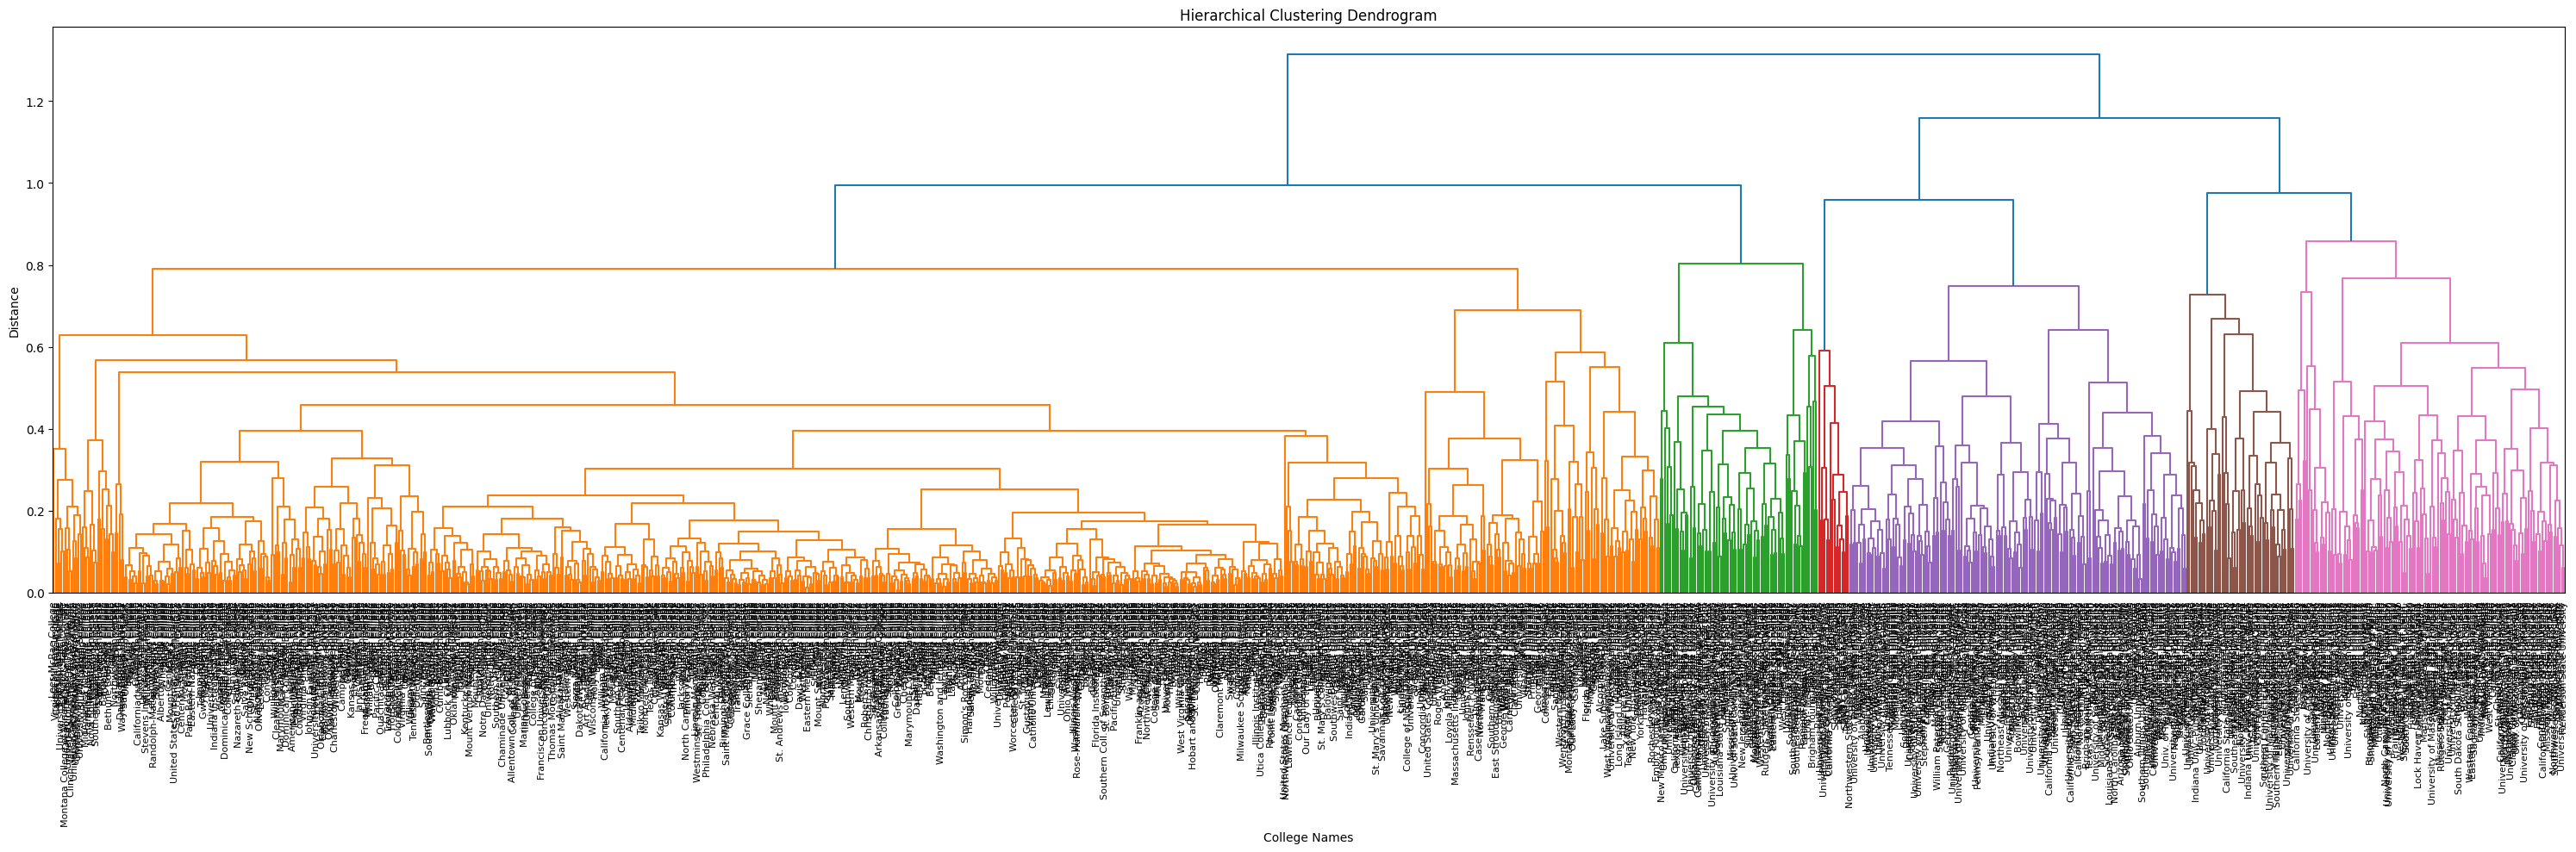

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Select only continuous features for clustering
continuous_features = univ.select_dtypes(include=['number'])

# Normalize the continuous features
normalized_data = normalize(continuous_features)

# Perform hierarchical clustering with complete linkage and Euclidean distance
mergings = linkage(normalized_data, method='complete', metric='euclidean')

# Plot the dendrogram with college names as labels
plt.figure(figsize=(30, 10))
dendrogram(mergings,
           labels=univ['College Name'].tolist(),  # Use college names as labels
           leaf_rotation=90,
           leaf_font_size=8,
           )
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('College Names')
plt.ylabel('Distance')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

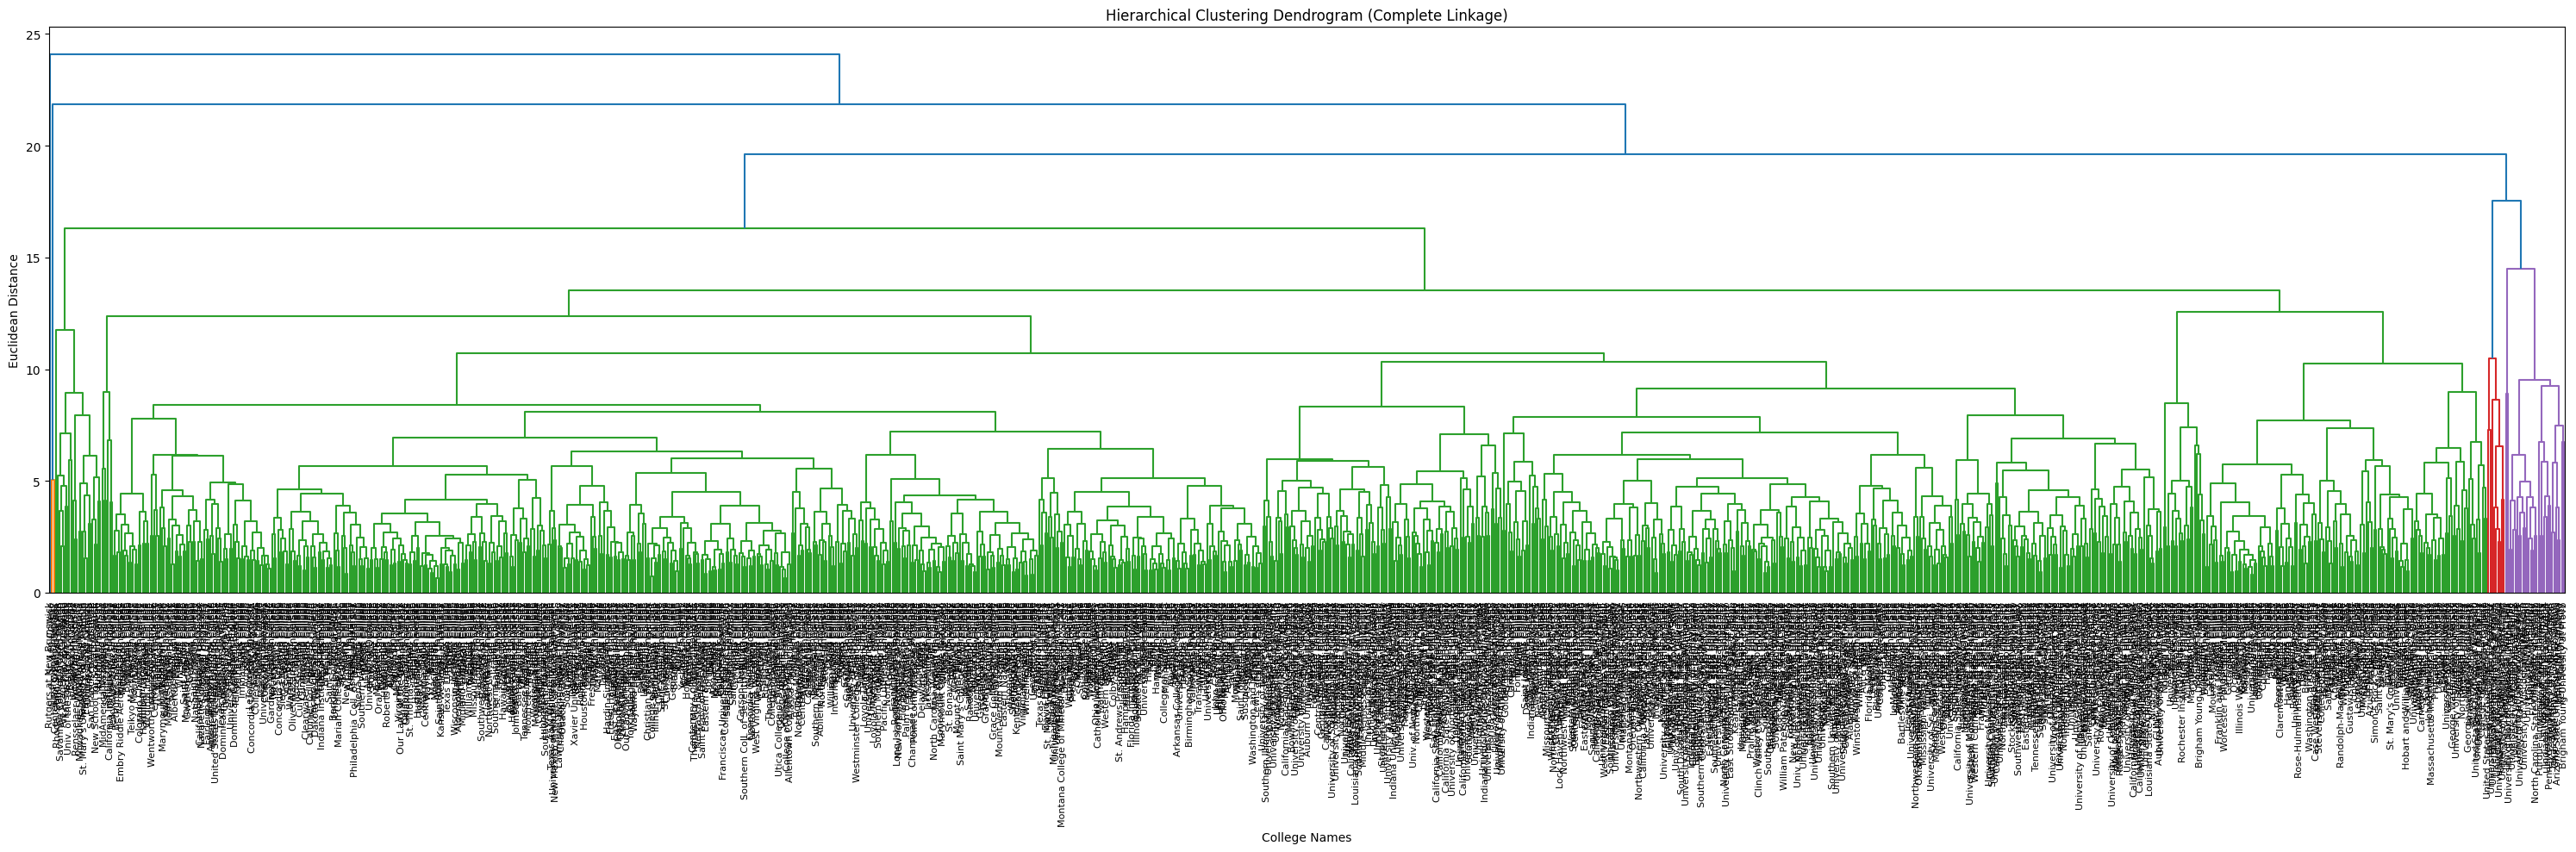

In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Step 1: Select only continuous features for clustering
continuous_features = univ.select_dtypes(include=['number'])

# Step 2: Standardize (z-score normalize) the continuous features
scaler = StandardScaler()
normalized_data = scaler.fit_transform(continuous_features)

# Step 3: Perform hierarchical clustering with complete linkage and Euclidean distance
mergings = linkage(normalized_data, method='complete', metric='euclidean')

# Step 4: Plot the dendrogram with college names as labels
plt.figure(figsize=(30, 10))
dendrogram(mergings,
           labels=univ['College Name'].tolist(),  # Use college names as labels
           leaf_rotation=90,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('College Names')
plt.ylabel('Euclidean Distance')
plt.tight_layout()  # Adjust layout to prevent label overlap
plt.show()


**Compare the summary statistics for each cluster and describe each cluster in this context (e.g., “Universities with high tuition, low acceptance rate…”). **

### **Assignment2**

In [66]:
data = pd.read_csv('/content/ToyotaCorolla.csv')

In [67]:
data.head()

,Id,Model,Price,Age (month),Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age (month)        1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


In [69]:
data.isnull().sum().sum()

np.int64(0)

In [70]:
# prompt: remove the dublicate values
data.shape
# data.drop_duplicates(inplace=True)


(1436, 39)

In [71]:
# prompt: check the dublicate rows

data.duplicated().sum()


np.int64(0)

In [72]:
data1=data.copy()
data1.head()

,Id,Model,Price,Age (month),Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [73]:
data1.drop_duplicates(inplace=True)

In [74]:
data1.shape

(1436, 39)

**Identify the categorical variables. **

In [76]:
# prompt: Identify the categorical variables.


# Similarly for the second dataset
categorical_variables_toyota = data.select_dtypes(include=['object']).columns
print("\nCategorical Variables (Toyota):", categorical_variables_toyota)



Categorical Variables (Toyota): Index(['Model', 'Fuel_Type', 'Color'], dtype='object')


In [80]:
# prompt:  the relationship between a categorical variable and the series of binary dummy variables derived from it.

import pandas as pd
# Create dummy variables for categorical variables
categorical_cols = ['Fuel_Type', 'Color', 'Automatic', 'Met_Color']  # Example categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Display the encoded DataFra
data_encoded.head()

# Relationship explanation:
# Each original categorical variable is replaced by a series of binary (0 or 1) dummy variables.
# The number of dummy variables created for a categorical variable is one less than the number of unique categories in that variable (due to the drop_first=True argument).  This prevents multicollinearity.
# Each dummy variable represents a specific category. A value of 1 indicates that the observation belongs to that category, while a value of 0 indicates that it does not.

# Example:
# If the 'Fuel_Type' variable has categories 'Petrol', 'Diesel', and 'CNG', and drop_first=True is used:
# - 'Fuel_Type_Diesel' and 'Fuel_Type_CNG' will be created.
# - A record with 'Fuel_Type' = 'Diesel' will have: Fuel_Type_Diesel=1, Fuel_Type_CNG=0
# - A record with 'Fuel_Type' = 'Petrol' (the dropped category) will have: Fuel_Type_Diesel=0, Fuel_Type_CNG=0
# - A record with 'Fuel_Type' = 'CNG' will have: Fuel_Type_Diesel=0, Fuel_Type_CNG=1

# This encoding allows machine learning algorithms that work with numerical data to utilize the information contained in the categorical variables effectively.


,Id,Model,Price,Age (month),Mfg_Month,Mfg_Year,KM,HP,CC,Doors,...,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Automatic_1,Met_Color_1
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,90,2000,3,...,True,False,False,False,False,False,False,False,False,True
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,90,2000,3,...,False,False,False,False,True,False,False,False,False,True
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,90,2000,3,...,True,False,False,False,False,False,False,False,False,True
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,90,2000,3,...,False,False,False,False,False,False,False,False,False,False
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,90,2000,3,...,False,False,False,False,False,False,False,False,False,False
